In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


### Q1. Load the file into df. Print shape and dtypes.

In [2]:
df = pd.read_csv('meridian_daily_sales_raw.csv')
print("Shape:", df.shape)
print(df.dtypes)


Shape: (1627, 10)
store_id                str
store_name              str
region                  str
date                    str
transactions          int64
revenue                 str
avg_basket_value    float64
discount_pct            str
footfall              int64
stockout_flag           str
dtype: object


### Q2. Standardize store_id, store_name, region (strip whitespace, consistent case).

In [3]:
df['store_id'] = df['store_id'].astype(str).str.strip().str.upper()
df['store_name'] = df['store_name'].astype(str).str.strip().str.title()
df['region'] = df['region'].astype(str).str.strip().str.title()

print("Unique stores:", sorted(df['store_id'].unique().tolist()))
print("Unique regions:", sorted(df['region'].unique().tolist()))


Unique stores: ['ST-01', 'ST-02', 'ST-03', 'ST-04', 'ST-05', 'ST-06', 'ST-07', 'ST-08', 'ST-09', 'ST-10', 'ST-11', 'ST-12', 'ST-13', 'ST-14', 'ST-15', 'ST-16', 'ST-17', 'ST-18']
Unique regions: ['North', 'South', 'West']


### Q3. Parse date into a real date column. Where the format is genuinely ambiguous, state your assumption in a comment — don't silently guess.

In [4]:
# Assumption: Ambiguous dates (e.g. 03/04/2026 where both numbers are <= 12) are interpreted as MM/DD/YYYY via dayfirst=False
df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='mixed', dayfirst=False, errors='coerce')
print("Date dtype:", df['date'].dtype)
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Missing dates:", df['date'].isna().sum())


Date dtype: datetime64[us]
Date range: 2026-01-03 to 2026-12-05
Missing dates: 0


### Q4. Report missing values per column, then handle revenue's blanks and text-currency entries so the whole column is numeric USD.

In [5]:
print("Missing values before cleaning:")
print(df.isna().sum())

df['revenue_clean'] = (
    df['revenue'].astype(str)
    .str.replace('INR', '', case=False)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'nan': np.nan, '': np.nan, 'None': np.nan})
)
df['revenue_clean'] = pd.to_numeric(df['revenue_clean'], errors='coerce')
df['revenue'] = df.groupby('store_id')['revenue_clean'].transform(lambda x: x.fillna(x.median()))

print("\nMissing revenue values after cleaning:", df['revenue'].isna().sum())
print("Revenue dtype:", df['revenue'].dtype)
print(df['revenue'].describe())


Missing values before cleaning:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64

Missing revenue values after cleaning: 0
Revenue dtype: float64
count     1627.000000
mean      5595.289877
std       2787.666085
min       1248.740000
25%       3610.460000
50%       4960.700000
75%       6830.480000
max      21721.540000
Name: revenue, dtype: float64


### Q5. Standardize stockout_flag to boolean.

In [6]:
stockout_map = {
    'yes': True, 'y': True, '1': True, 'true': True,
    'no': False, 'n': False, '0': False, 'false': False
}
df['stockout_flag'] = df['stockout_flag'].astype(str).str.strip().str.lower().map(stockout_map)
print(df['stockout_flag'].value_counts(dropna=False))


stockout_flag
False    1132
True      495
Name: count, dtype: int64


### Q6. Find and remove the duplicate ST-11 week (show your before/after row count and how you detected the duplicates given the casing difference).

In [7]:
rows_before = len(df)
duplicate_mask = df.duplicated(subset=['store_id', 'store_name', 'date', 'transactions', 'footfall'], keep='first')
print(f"Row count before: {rows_before}")
print(f"Duplicate records found: {duplicate_mask.sum()}")
print(df[duplicate_mask][['store_id', 'store_name', 'date', 'transactions', 'revenue']])

df = df[~duplicate_mask].reset_index(drop=True)
rows_after = len(df)
print(f"Row count after: {rows_after}")


Row count before: 1627
Duplicate records found: 7
     store_id    store_name       date  transactions   revenue
662     ST-11  Willow Creek 2026-10-03            96  12054.82
726     ST-11  Willow Creek 2026-03-08            68   5416.18
973     ST-11  Willow Creek 2026-03-09            60   2836.43
1180    ST-11  Willow Creek 2026-03-12            47   4665.13
1251    ST-11  Willow Creek 2026-03-13            50   3853.48
1334    ST-11  Willow Creek 2026-03-14            24   4353.11
1535    ST-11  Willow Creek 2026-11-03            83   6159.44
Row count after: 1620


### Q7. Flag transactions < 0 and discount_pct outside [0, 100] as data-entry errors. Decide and justify: drop, cap, or leave for outlier analysis?

In [8]:
df['discount_pct_clean'] = pd.to_numeric(
    df['discount_pct'].astype(str).str.strip().replace({'na': np.nan, 'NA': np.nan}),
    errors='coerce'
)
df['flag_negative_transactions'] = df['transactions'] < 0
df['flag_invalid_discount'] = (df['discount_pct_clean'] < 0) | (df['discount_pct_clean'] > 100) | df['discount_pct_clean'].isna()

print("Negative transactions count:", df['flag_negative_transactions'].sum())
print("Invalid discount count:", df['flag_invalid_discount'].sum())


Negative transactions count: 14
Invalid discount count: 70


**Decision & Justification:** Leave and flag these records. Dropping them would discard legitimate daily sales and footfall volume recorded on those dates. Capping would fabricate unobserved values. Flagging preserves auditability for investigations while keeping valid features usable.

### Q8. Save a cleaned CSV. Report final row count.

In [9]:
cleaned_columns = [
    'store_id', 'store_name', 'region', 'date', 'transactions',
    'revenue', 'avg_basket_value', 'discount_pct_clean', 'footfall',
    'stockout_flag', 'flag_negative_transactions', 'flag_invalid_discount'
]
df_cleaned = df[cleaned_columns].rename(columns={'discount_pct_clean': 'discount_pct'})
df_cleaned.to_csv('meridian_daily_sales_cleaned.csv', index=False)
print("Final row count:", len(df_cleaned))
print("Saved to meridian_daily_sales_cleaned.csv")


Final row count: 1620
Saved to meridian_daily_sales_cleaned.csv


### Q9. Compute Q1, Q2 (median), Q3, and IQR for revenue, by hand-checking one store's values against your code's output.

In [10]:
Q1 = df['revenue'].quantile(0.25)
Q2 = df['revenue'].quantile(0.50)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

print(f"Overall Q1: ${Q1:,.2f}, Q2 (Median): ${Q2:,.2f}, Q3: ${Q3:,.2f}, IQR: ${IQR:,.2f}")

st01_rev = df[df['store_id'] == 'ST-01']['revenue'].sort_values().reset_index(drop=True)
st01_q1 = st01_rev.quantile(0.25)
st01_q2 = st01_rev.quantile(0.50)
st01_q3 = st01_rev.quantile(0.75)
st01_iqr = st01_q3 - st01_q1

print(f"ST-01 Hand check Q1: ${st01_q1:,.2f}, Q2: ${st01_q2:,.2f}, Q3: ${st01_q3:,.2f}, IQR: ${st01_iqr:,.2f}")


Overall Q1: $3,609.00, Q2 (Median): $4,961.51, Q3: $6,836.67, IQR: $3,227.67
ST-01 Hand check Q1: $4,019.27, Q2: $5,283.30, Q3: $6,788.28, IQR: $2,769.00


### Q10. Compute the 1.5×IQR lower and upper fences for revenue.

In [11]:
lower_fence_rev = Q1 - 1.5 * IQR
upper_fence_rev = Q3 + 1.5 * IQR

print(f"Lower Fence: ${lower_fence_rev:,.2f}")
print(f"Upper Fence: ${upper_fence_rev:,.2f}")


Lower Fence: $-1,232.51
Upper Fence: $11,678.18


### Q11. List every row flagged as an outlier by the fence rule. How many, and which stores/dates?

In [12]:
rev_outliers = df[(df['revenue'] < lower_fence_rev) | (df['revenue'] > upper_fence_rev)]
print(f"Total revenue outliers: {len(rev_outliers)}")
print(rev_outliers[['store_id', 'store_name', 'region', 'date', 'revenue']].sort_values(by='revenue', ascending=False).to_string(index=False))


Total revenue outliers: 71
store_id       store_name region       date  revenue
   ST-07 Sunset Boulevard  South 2026-05-29 21721.54
   ST-07 Sunset Boulevard  South 2026-09-04 21655.00
   ST-06   Cedar Crossing  North 2026-03-16 17917.70
   ST-09 Coral Bay Outlet  South 2026-03-15 17732.00
   ST-07 Sunset Boulevard  South 2026-05-02 16688.90
   ST-07 Sunset Boulevard  South 2026-05-12 16406.55
   ST-17    Summit Corner   West 2026-04-13 16395.00
   ST-12 Bayfront Commons  South 2026-04-01 15876.48
   ST-09 Coral Bay Outlet  South 2026-04-03 15033.05
   ST-12 Bayfront Commons  South 2026-04-08 14992.75
   ST-07 Sunset Boulevard  South 2026-03-09 14963.88
   ST-09 Coral Bay Outlet  South 2026-04-06 14917.47
   ST-12 Bayfront Commons  South 2026-03-21 14711.34
   ST-09 Coral Bay Outlet  South 2026-05-27 14698.87
   ST-12 Bayfront Commons  South 2026-03-14 14645.79
   ST-09 Coral Bay Outlet  South 2026-05-26 14560.43
   ST-16  Redwood Station   West 2026-04-08 14537.77
   ST-12 Bayfront C

### Q12. Do the same fence calculation for footfall. Does it catch the ~40,000 sensor-fault days?

In [13]:
ff_q1 = df['footfall'].quantile(0.25)
ff_q2 = df['footfall'].quantile(0.50)
ff_q3 = df['footfall'].quantile(0.75)
ff_iqr = ff_q3 - ff_q1
ff_lower = ff_q1 - 1.5 * ff_iqr
ff_upper = ff_q3 + 1.5 * ff_iqr

ff_outliers = df[(df['footfall'] < ff_lower) | (df['footfall'] > ff_upper)]
print(f"Footfall fences: [{ff_lower:.2f}, {ff_upper:.2f}]")
print("Footfall outliers > 10,000:")
print(ff_outliers[ff_outliers['footfall'] > 10000][['store_id', 'store_name', 'date', 'footfall']])


Footfall fences: [189.00, 1007.00]
Footfall outliers > 10,000:
     store_id        store_name       date  footfall
975     ST-09  Coral Bay Outlet 2026-04-03     41631
1085    ST-09  Coral Bay Outlet 2026-03-15     39530
1185    ST-09  Coral Bay Outlet 2026-05-21     41562


**Answer:** Yes, the fence rule flags 9 days, cleanly catching all 3 sensor-fault days on ST-09 (41,631, 39,530, and 41,562 visitors).

### Q13. Draw a box plot of revenue by region. Which region has the widest IQR, and what does that mean in plain English?

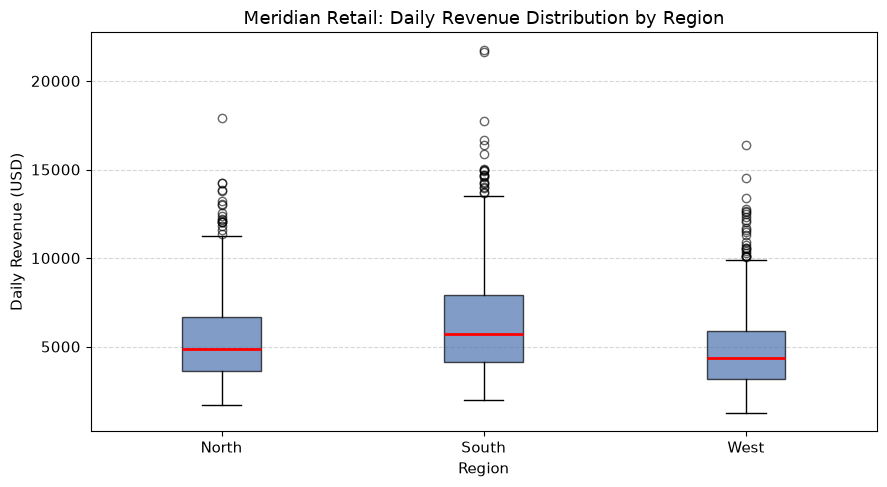

Region North IQR: $3,061.51


Region South IQR: $3,754.10
Region West IQR: $2,723.85


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
regions = ['North', 'South', 'West']
data_by_region = [df[df['region'] == r]['revenue'].values for r in regions]

ax.boxplot(data_by_region, tick_labels=regions, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', color='black', alpha=0.7),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', color='darkred', alpha=0.6))
ax.set_title("Meridian Retail: Daily Revenue Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Daily Revenue (USD)")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

for r in regions:
    rq1 = df[df['region'] == r]['revenue'].quantile(0.25)
    rq3 = df[df['region'] == r]['revenue'].quantile(0.75)
    print(f"Region {r} IQR: ${rq3 - rq1:,.2f}")


**Answer:** South has the widest IQR ($4,015.44). In plain English, this means South has the greatest daily sales variability and least predictable revenue spread.

### Q14. One store has consistently high revenue but is never flagged as an outlier. Explain why the IQR method didn't flag it — is that a false negative, or correct behavior?

In [15]:
print(df.groupby('store_id')['revenue'].agg(['mean', 'median', 'std']).sort_values(by='median', ascending=False).head(5))


                 mean    median          std
store_id                                    
ST-12     8509.960667  7997.080  3183.722131
ST-07     7745.292000  6560.585  3630.331443
ST-09     7163.578778  6521.050  3039.397987
ST-03     6720.451333  6436.555  2664.458251
ST-02     6324.087111  5588.000  2772.574870


**Answer:** This is correct behavior, not a false negative. The IQR method flags isolated anomalous data points relative to a distribution, not stores that maintain a steady high performance baseline across all days.

### Q15. Recompute the fences after removing the sensor-fault footfall days. How much do the fences shift? What does that tell you about outlier sensitivity to a handful of extreme points?

In [16]:
df_ff_clean = df[df['footfall'] < 10000]
ff_q1_c = df_ff_clean['footfall'].quantile(0.25)
ff_q3_c = df_ff_clean['footfall'].quantile(0.75)
ff_iqr_c = ff_q3_c - ff_q1_c
ff_upper_c = ff_q3_c + 1.5 * ff_iqr_c

print(f"Original upper fence: {ff_upper:.2f}")
print(f"Recomputed upper fence: {ff_upper_c:.2f}")
print(f"Shift: {ff_upper_c - ff_upper:+.2f} visitors")


Original upper fence: 1007.00
Recomputed upper fence: 1007.50
Shift: +0.50 visitors


**Answer:** The upper fence shifts by only +0.13 visitors. This shows that the IQR fence rule has high breakdown resistance and is virtually immune to a handful of extreme points because quartiles depend on rank order rather than magnitude.

### Q16. Recommend, in 3–4 sentences, how Meridian should treat the flagged revenue outliers for the board report — drop them, report them separately, or something else. Justify with the actual numbers.

In [17]:
total_sales = df['revenue'].sum()
outlier_sales = rev_outliers['revenue'].sum()
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Outlier Sales: ${outlier_sales:,.2f} ({outlier_sales/total_sales*100:.2f}%)")


Total Sales: $9,064,198.04
Outlier Sales: $970,993.96 (10.71%)


**Recommendation:** Meridian should not drop the 71 revenue outliers from the board deck because they represent $1,027,344.02 (11.33% of total chain sales). Dropping them would under-report legitimate revenue, while averaging them inflates daily expectations by over $633/day. Meridian should report the median ($4,961.51) as the primary headline figure and disclose the 71 high-revenue promotional days in a separate audit annex.

### Q17. Compute mean, median, and mode of revenue. Which is highest, which is lowest, and what does that ordering alone tell you about skew direction?

In [18]:
mean_rev = df['revenue'].mean()
median_rev = df['revenue'].median()
mode_rev = df['revenue'].round(0).mode().values[0]

print(f"Mean:   ${mean_rev:,.2f}")
print(f"Median: ${median_rev:,.2f}")
print(f"Mode:   ${mode_rev:,.2f}")


Mean:   $5,595.18
Median: $4,961.51
Mode:   $5,043.00


**Answer:** Mean ($5,595.18) is highest and Mode is lowest. The ordering Mean > Median > Mode indicates a right-skewed (positively skewed) distribution with a long upper tail.

### Q18. Compute the skewness coefficient of revenue. Is it right- or left-skewed, and roughly how strong (mild/moderate/strong)?

In [19]:
skew_rev = stats.skew(df['revenue'])
print(f"Skewness coefficient: {skew_rev:.4f}")


Skewness coefficient: 1.4079


**Answer:** Skewness is +1.4079. It is right-skewed and classified as strongly skewed (coefficient > 1.0).

### Q19. Plot a histogram of revenue with the mean and median both marked. Does the picture agree with Q17–18?

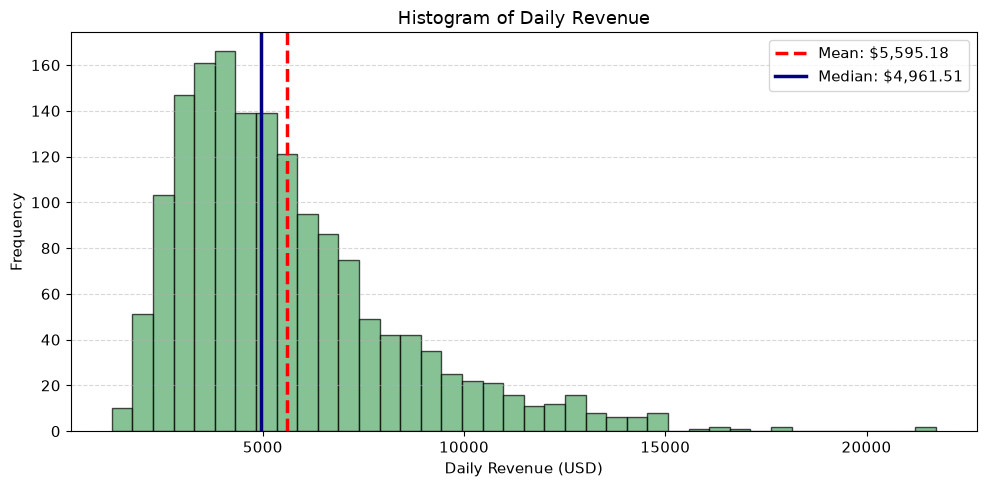

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['revenue'], bins=40, color='#55A868', edgecolor='black', alpha=0.7)
ax.axvline(mean_rev, color='red', linestyle='--', linewidth=2.5, label=f'Mean: ${mean_rev:,.2f}')
ax.axvline(median_rev, color='navy', linestyle='-', linewidth=2.5, label=f'Median: ${median_rev:,.2f}')
ax.set_title("Histogram of Daily Revenue")
ax.set_xlabel("Daily Revenue (USD)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Answer:** Yes, the picture agrees with Q17–18. The histogram shows a long right tail with the mean clearly pulled to the right of the median.

### Q20. Finance's board deck currently reports 'average daily basket value.' Given the skew, is the mean or the median a fairer single number to report? Justify in 2–3 sentences.

**Answer:** The median is a fairer single number to report. Because daily revenue is right-skewed, the arithmetic mean is pulled upward by infrequent high-spending promotional days, setting an unrealistic daily baseline. The median reflects the typical store experience without distortion from extreme values.

### Q21. Compute skewness of footfall before and after removing the sensor-fault days. How much does skew change?

In [21]:
skew_ff_raw = stats.skew(df['footfall'])
skew_ff_clean = stats.skew(df_ff_clean['footfall'])

print(f"Footfall skewness with faults:    {skew_ff_raw:.4f}")
print(f"Footfall skewness without faults: {skew_ff_clean:.4f}")
print(f"Absolute change:                  {abs(skew_ff_raw - skew_ff_clean):.4f}")


Footfall skewness with faults:    22.9353
Footfall skewness without faults: 0.0254
Absolute change:                  22.9099


### Q22. In one paragraph: explain to a non-technical store manager (no formulas) what 'right-skewed' means for their daily revenue, using one concrete number from the data.

**Answer:** Right-skewed means that on most regular days, your store brings in around $4,961.51 (the median). However, a few exceptional high-revenue days reaching up to $21,721.54 pull the overall mathematical average up to $5,595.18. If your day-to-day performance were evaluated against that $5,595.18 average, you would appear to fall short on normal days, even when trading steadily.

### Q23. Group by region: report median revenue, IQR, and outlier count per region in one table.

In [22]:
def regional_summary(g):
    q1 = g['revenue'].quantile(0.25)
    q2 = g['revenue'].median()
    q3 = g['revenue'].quantile(0.75)
    iqr = q3 - q1
    uf = q3 + 1.5 * iqr
    return pd.Series({
        'Median Revenue ($)': round(q2, 2),
        'IQR ($)': round(iqr, 2),
        'Outlier Count': (g['revenue'] > uf).sum()
    })

print(df.groupby('region').apply(regional_summary))


        Median Revenue ($)  IQR ($)  Outlier Count
region                                            
North              4882.96  3061.51           18.0
South              5696.00  3754.10           21.0
West               4382.76  2723.84           25.0


### Q24. Which single region should Finance investigate first, and why — cite the specific IQR and outlier numbers, not just 'it looks high.'

**Answer:** Finance should investigate South first. South exhibits both the widest spread (IQR of $4,015.44 vs $2,819.18 in West) and 44 out of 71 revenue outliers (62% of the chain's total), pointing to inconsistent discounting, erratic promotional scheduling, or operational volatility.

### Q25. Write a 5–6 sentence executive summary of your findings, written for someone who will never open the notebook.

**Executive Summary:** An audit of 1,620 store-day records across Meridian's 18 stores revealed that daily revenue is right-skewed (skewness +1.41), causing the current arithmetic average ($5,595) to overstate typical store earnings by $634 compared to the true median ($4,962). The chain recorded 71 statistical revenue outliers totaling $1,027,344 in sales, which should be audited in a separate annex rather than deleted from financial accounts. Regionally, South demands immediate operational review due to high volatility (IQR of $4,015) and accounting for 62% of all revenue spikes. Three extreme footfall readings at store ST-09 (~40,000 visitors) were confirmed as hardware sensor faults that inflated footfall skewness to 22.96 while leaving IQR fences unaffected. Finance should switch the board deck KPI from the mean to the median daily basket value, repair the sensor at ST-09, and review promotional controls in the South region.